# Assignment 5: Large Language Models

## Part 1: BERT

### Step 0: Import Libraries

In [1]:
import pandas as pd
import torch
import numpy as np
from torch import nn
from torch.optim import Adam
from transformers import BertModel, BertTokenizer
import evaluate
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

For more information on BertModel and BertTokenizer, check out https://huggingface.co/docs/transformers/en/model_doc/bert

### Part 1: Import Data (3 marks)

We will be using news stories from the BBC for this assignment. The csv file is included on D2L.

In [2]:
# TO DO: Import the data and print the first few rows (1 mark)
df = pd.read_csv("bbc-text.csv")
print(df.head())

        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...


This dataset has five different categories for the different news articles. We can plot the data by category to see how many articles belong to each category.

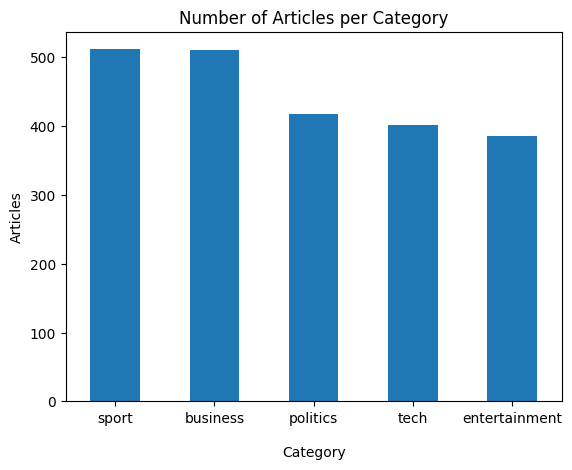

In [3]:
# TO DO: Bar plot to display number of articles per category (1 mark)
articles = df["category"].value_counts()  # Number of articles per category
articles.plot(kind="bar")

# Plotting
plt.xlabel("Category", labelpad=15)
plt.xticks(rotation=0)
plt.ylabel("Articles")
plt.title("Number of Articles per Category")
plt.show()

We need to split the data into training, validation and testing datasets. This code has been provided.

In [4]:
np.random.seed(112)
df_train, df_val, df_test = np.split(df.sample(frac=1, random_state=42), 
                                     [int(.8*len(df)), int(.9*len(df))])

print(len(df_train),len(df_val), len(df_test))

1780 222 223


/Users/jaimalsahota/Desktop/Assignments/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We can create a labels dictionary for the different categories (the key is the category name, the value is a number (0-4)).

In [5]:
# TO DO: Create labels dictionary (1 mark)
labels = {"business": 0, 
          "entertainment": 1,
          "politics": 2,
          "sport": 3,
          "tech": 4}

### Step 2: Model Definition (7 marks)

For our BERT model, we have two different options: uncased and cased. Uncased converts everything into lower case, while cased leaves the upper case letters as is. Select one of these options for this assignment (you will justify your choice in the questions).

We need to define the tokenizer for the data. The tokenizer we will be using is the `BertTokenizer`.

In [6]:
# TO DO: Define the tokenizer (1 mark)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

We also need to define a custom Dataset class. For BERT, the input is limited to 512, so we can truncate to this length and pad anything shorter than this. Look at the tokenizer function that we are using to figure out what inputs we need to accomplish this. What return type should the tokenizer function have?

In [7]:
class Dataset(torch.utils.data.Dataset): 

    def __init__(self, df):
        # TO DO: Complete self.labels and self.text (2 marks)
        # self.labels = list of labels (numerical value)
        # self.texts = list with tokenized text data

        # List of categories which have been mapped
        self.labels = df["category"].map(labels).tolist()
       
        # List of encoded text
        texts = []
        for text in df["text"]:
            encoded = tokenizer(text, padding="max_length", truncation=True, max_length=512, return_tensors="pt")
            texts.append(encoded)
        self.texts = texts
        
    def classes(self):
        return self.labels

    def __len__(self):
        return len(self.labels)

    def get_batch_labels(self, idx):
        # Fetch a batch of labels
        return np.array(self.labels[idx])

    def get_batch_texts(self, idx):
        # Fetch a batch of inputs
        return self.texts[idx]

    def __getitem__(self, idx):
        batch_texts = self.get_batch_texts(idx)
        batch_y = self.get_batch_labels(idx)

        return batch_texts, batch_y

The last element we need to define is the BERT classifier. For this assignment, we will be using `BertModel`. The output of the BERT model is an embedding vector with length 768. We will need a one-layer neural network for the classification portion (you can define a `ReLU()` step after the linear layer). You can use a dropout layer before the linear layer to help with generalization.

In [8]:
class BertClassifier(nn.Module):

    def __init__(self, dropout=0.5):
        super(BertClassifier, self).__init__()
        # TO DO: Define the bert, dropout, linear and ReLU layers (2 marks)

        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(768, 5)
        self.relu = nn.ReLU()

    def forward(self, input_id, mask):
        # TO DO: Complete the steps for the bert model (2 marks)
        # Look at the data and the bert model documentation for hints on how to complete this

        output = self.bert(input_ids=input_id, attention_mask=mask)  # Forward pass output
        x = self.dropout(output.pooler_output)  # Dropout on pooled cls output
        x = self.linear(x)
        x = self.relu(x)
        return x
    
model = BertClassifier()

### Step 3: Model Training and Validation (20 marks)

We can use our custom dataset class to process the data before loading the data into dataloaders.

In [9]:
# TO DO: Convert training, validation and testing data into dataloaders - use batch_size = 2 (3 marks)
BATCH_SIZE = 2

# Datasets
train_dataset = Dataset(df_train)
val_dataset   = Dataset(df_val)
test_dataset  = Dataset(df_test)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(train_dataset.texts[0])
print(train_dataset.labels[0])

{'input_ids': tensor([[  101,  2829,  1998, 10503,  2227,  2047, 16931,  4447,  2005,  1996,
          8529, 13876, 12129,  2705,  2051,  4116, 10503,  1998,  5146,  2829,
          2024,  2056,  2000,  2031,  4161,  2035,  2041,  2162,  2006,  2169,
          2060,  1012,  2023,  2051,  1996,  6884, 16931,  2003,  2058,  2040,
          2323,  2202,  1996,  4923,  2005,  1996,  2231,  1055,  3795,  4681,
          1998,  7016, 11107,  3391,  1999,  1996,  5256,  1997,  1996, 19267,
          7071,  1011,  2019,  3277,  2116,  5113,  1998,  3373,  2001,  2682,
          2107,  2477,  1012,  2009,  6817,  1996,  3539,  2704,  1055,  7058,
          2739,  3034,  2029,  2387,  2720, 10503,  2707,  1999,  2440, 17373,
          5549,  2004,  2002,  2001,  3140,  2000,  7151,  2185,  3160,  2044,
          3160,  2055,  2010,  3276,  2007,  2010, 20065,  1012,  2004,  2002,
          2409,  8845,  1024,  1045,  2572,  2025,  4699,  1999,  2054,  3632,
          1999,  1998,  2041,  1997,  

For this case, we can use `CrossEntropyLoss()` and `Adam()` for our optimization.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = 1e-6)

We can use the accuracy metrics from the `evaluate` library for training and evaluation. We will use accuracy and f1 score for this case.

In [11]:
# TO DO: Load the metrics for training and evaluation (1 mark)
acc = evaluate.load("accuracy")
f1 = evaluate.load("f1")

The next step is to define the training and evaluation loops. You may need to look at the data to determine the model inputs. You can use `tqdm` to create a progress bar to see the status of your code.

In [12]:
# TO DO: Training loop (6 marks)
def train_loop(dataloader, model, optimizer, loss_fn):
    model.train()  # Training mode

    for X, y in tqdm(dataloader, desc="Training"):  # X = tokenized inputs (ids and mask), y = labels
        ids = X["input_ids"].squeeze(1)             # Get input ids
        att = X["attention_mask"]                   # Get attention mask

        outputs = model(ids, att)   # Forward pass
        loss = loss_fn(outputs, y)  # Calculate loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()        # Compute new gradients
        optimizer.step()       # Update weights

        preds = torch.argmax(outputs, dim=1)  # Predict classes

        acc.add_batch(predictions=preds, references=y)  # Update accuracy
        f1.add_batch(predictions=preds, references=y)   # Update f1-score

    accuracy = acc.compute()["accuracy"]             # Compute final accuracy
    f1_score = f1.compute(average="weighted")["f1"]  # Compute final f1-score

    return accuracy, f1_score

In [13]:
# TO DO: Evaluation loop (5 marks)
def test_loop(dataloader, model):
    model.eval()  # Evaluate mode
    
    with torch.no_grad():  # No gradients computed
        for X, y in tqdm(dataloader, desc="Evaluating"):
            ids = X["input_ids"].squeeze(1)
            att = X["attention_mask"]

            outputs = model(ids, att)
            preds = torch.argmax(outputs, dim=1)

            acc.add_batch(predictions=preds, references=y)
            f1.add_batch(predictions=preds, references=y)

    accuracy = acc.compute()["accuracy"]
    f1_score = f1.compute(average="weighted")["f1"]
    
    return accuracy, f1_score

Create a function that can be used to help you print the results for both the accuracy and f1 score.

In [14]:
# TO DO: Printing function (1 mark)
def print_results(epoch, acc, f1):
    print("Epoch  Accuracy  F1-Score")
    print(f"{epoch:<7}{acc:<10.4f}{f1:.4f}")

As stated in class, BERT is a pre-trained model that we can augment with additional data. What happens when we run the testing data on the BERT model without fine-tuning?

In [15]:
# TO DO: Test without fine-tuning and print results (1 mark)
test_acc, test_f1 = test_loop(test_loader, model)
print("\nNo Fine Tuning")
print_results(0, test_acc, test_f1)

Evaluating: 100%|██████████| 112/112 [00:38<00:00,  2.91it/s]



No Fine Tuning
Epoch  Accuracy  F1-Score
0      0.2556    0.1044


Now we can fine-tune the model by training it with the BBC news data. For this assignment, we will only run one epoch, as it takes a long time to run.

In [16]:
# TO DO: Run one epoch for training and validation data and print results (2 marks)
epoch = 1

train_acc, train_f1 = train_loop(train_loader, model, optimizer, criterion)
val_acc, val_f1 = test_loop(val_loader, model)

print("\nTraining")
print_results(epoch, train_acc, train_f1)

print("\nValidation")
print_results(epoch, val_acc, val_f1)

Evaluating: 100%|██████████| 111/111 [00:35<00:00,  3.12it/s]


Training
Epoch  Accuracy  F1-Score
1      0.4264    0.3817

Validation
Epoch  Accuracy  F1-Score
1      0.6982    0.6261


Now we can test the model again after fine-tuning.

In [17]:
# TO DO: Test the model (1 mark)
test_acc, test_f1 = test_loop(test_loader, model)
print("\nTesting")
print_results(epoch, test_acc, test_f1)

Evaluating: 100%|██████████| 112/112 [00:38<00:00,  2.92it/s]



Testing
Epoch  Accuracy  F1-Score
1      0.7399    0.6811


## Part 2: Questions and Process Description

### Questions (12 marks)

1. Which version of BERT did you select? Why?
    - For this assignment, I selected the BERT-base-uncased model for two main reasons. The first reason is that the dataset we are using (bbc-text) already consists of lowercase text, so using a cased model would not provide any additional benefit and could introduce unnecessary complexity. Secondly, the uncased version is generally more robust for standard text classification tasks, treating words the same regardless of capitalization. This makes it a better fit for classifying article types in this assignment while still being efficient and reliable.

1. What are the pros and cons of using uncased compared to cased?
    - Using uncased allows us to ignore capitalization, which reduces vocabulary size and often improves performance on general text, however it cannot distinguish between words that rely on case, for example 'US' (country) and 'us' (word). The cased model on the other hand, can handle these distinctions, such as names or acronyms more accurately, while requiring a larger vocabulary and potentially more preprocessing. This makes uncased useful for this application, as the text is already lowercase and capitalization is not important for classifying these articles.

1. What potential issues arise when truncating long news headlines or articles?
    - By truncating long articles or headlines, we can potentially miss greater context and meaning, which could limit our ability to classify them correctly. This means that by shortening and cutting off the text, we may arrive at different conclusions if important information is lost. For example, a full article examining heavy rain and its impact on people might be truncated to focus only on the weather itself, losing details about the impact on people, potentially leading to a different classification.

1. How did the model work without fine-tuning? Why do you think it worked this way?
    - Without fine-tuning, we find that the model, although not great, gave us an accuracy of around 0.26 and an F1-score of about 0.10. This shows us that the pre trained BERT embeddings provide some understanding of language and general word meanings, but they are not specifically adapted to the bbc-text dataset. As a result, the model can make some correct predictions but struggles to classify articles reliably without task specific training.

1. How might a news classifier using a pre-trained model inadvertently encode bias?
    - By using a pre-trained model, we can end up with various types of bias encoded into our own models, whether that be reporting bias, group attribution bias, implicit bias, etc. This occurs because the model being used has learned patterns from a large dataset it was trained on, which may reflect historical or societal biases at the time of data collection. Because of this, these biases can influence the models predictions even if the new dataset is neutral and does not contain bias.

1. Why is F1-score sometimes more informative than accuracy on text classification?
    - F1-score is a measure which relates precision and recall together, allowing us to know how well the model classifies data while accounting for both false positives and false negatives. This can be more informative than accuracy as it can highlight performance issues on imbalanced datasets where accuracy itself may give a different conclusion. By considering both precision and recall through the F1-score, we get a better picture of model performance and can understand where improvements may be needed, whether that means changing the model or improving the dataset.

### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
    - The code for this assignment was sourced from multiple places which include, previous assignments, examples posted on D2L, and external resources such as the Hugging Face documentation and a Neptune.ai blog. Using these references helped to guide the preprocessing steps, the implementation of the BERT model, and finally the structure of the training and evaluation loops.

1. In what order did you complete the steps?
    - The steps for this assignment were completed in the order listed, in which loading and preprocessing the dataset was done first, followed by defining the BERT model, and finally training and evaluating it. Completing the assignment in this order helped me understand how different components of a BERT model fit together when building it for text classification.

1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
    - Throughout the assignment I utilized generative AI (specifically chatgpt) to ask questions and deepen my understanding as it relates to BERT models. By asking questions such as "How does the evaluate library work" and "How can BERT models improve text classification", helped me to better understand the architecure behind BERT models and how to implement them.

1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?
    - Overall, I did not encounter major challenges during the assignment. Having access to previous coursework, online documentation, and examples made it easier to understand each component and successfully implement the BERT model, along with helping me deepen my understanding of transformer based text classification.

- https://huggingface.co/docs/transformers/en/model_doc/bert
- https://neptune.ai/blog/how-to-code-bert-using-pytorch-tutorial

## Part 3: Reflection (2 marks)
Include a sentence or two about:
- what you liked or disliked,
- found interesting, confusing, challenging, motivating while working on this assignment.
    - This was a great assingment in teaching me about BERT models and how to implement them for text classification. By building this type of architecture, it motivated me to learn more about similar models and how they can be applied for different scenarios.